# Validation of the Structural-Break Procedure Using Simulated Data

This notebook validates the custom Bai–Perron-style structural-break procedure used in the study.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.bai_perron import BaiPerron

## Simulated Data with Known Structural Breaks

A synthetic series is generated with two known structural breaks at
observations 200 and 400.

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Define regime lengths and known breakpoints
n1 = 200
n2 = 200
n3 = 200
true_breaks = [200, 400]

# Define regime means and noise level
mean1 = 0.8
mean2 = 2.5
mean3 = 1.0
noise_sd = 0.10

# Generate the three regimes
regime1 = mean1 + np.random.normal(0, noise_sd, n1)
regime2 = mean2 + np.random.normal(0, noise_sd, n2)
regime3 = mean3 + np.random.normal(0, noise_sd, n3)

# Combine regimes into one simulated series
simulated_volatility = np.concatenate([
    regime1,
    regime2,
    regime3
])

In [ ]:
print(f"Number of observations: {len(simulated_data)}")
print(f"True breakpoints: {true_breaks}")

In [ ]:
# Plot the simulated series
plt.figure(figsize=(14, 5))

plt.plot(simulated_data, label="Simulated Series")

for i, bp in enumerate(true_breaks):
    plt.axvline(
        bp,
        linestyle="--",
        alpha=0.7,
        label="True Breakpoint" if i == 0 else None
    )

plt.title("Simulated Series with Known Structural Breaks")
plt.xlabel("Observation")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## Core Implementation Checks

### RSS Matrix

As an implementation check, residual sums of squares (RSS) are calculated for all admissible segments and stored in an RSS matrix.

This matrix supports the dynamic-programming diagnostic below, which evaluates whether the implementation can recover the known breakpoint locations when the number of breaks is specified in advance.

The dynamic-programming check is used only for validation. The final empirical procedure determines breakpoints using sequential supF-style testing with moving-block-bootstrap critical values.

In [ ]:
rss_matrix = bp._build_rss_matrix(
    simulated_volatility
)

print("RSS matrix shape:", rss_matrix.shape)

In [ ]:
# Construct the RSS matrix for all admissible segments
rss_matrix = bp._build_rss_matrix(
    simulated_volatility
)

print(f"RSS matrix shape: {rss_matrix.shape}")
print(f"Expected shape:   ({len(simulated_volatility)}, {len(simulated_volatility)})")

### Fixed-Breakpoint-Count Validation

As an intermediate validation step, dynamic programming is used to identify the segmentation that minimizes total RSS when the number of structural breaks is fixed.

In [ ]:
print(hasattr(bp, "_dynamic_programming"))

True


In [ ]:
# Run the dynamic-programming diagnostic
dp_results = bp._dynamic_programming(
    simulated_volatility
)

print(f"Dynamic-programming cost matrix shape: {dp_results['costs'].shape}")

dict_keys(['costs', 'breakpoints'])
Costs shape: (8, 600)


In [ ]:
# Recover breakpoint locations conditional on two known breaks
dp_breakpoints = bp._get_breakpoints(
    dp_results,
    n_breaks=2,
    n=len(simulated_volatility)
)

# Compare true vs estimated
print(f"True breakpoints:      {true_breaks}")
print(f"Estimated breakpoints: {dp_breakpoints}")

Estimated breakpoints: [200, 400]


### Efficient RSS Calculation

Because the structural-break procedure evaluates many candidate segments, the implementation uses cumulative sums and cumulative squared sums to calculate segment-level RSS efficiently.

In [ ]:
# Initialize the structural-break procedure for sequential checks
bp_test = BaiPerron(
    max_breaks=6,
    min_segment=50
)

bp_test._prepare_cumulative_sums(
    simulated_volatility
)

True
True


In [ ]:
# Identify the strongest candidate break in the full series
first_candidate = bp_test._best_additional_break(
    0,
    len(simulated_volatility)
)

best_break = first_candidate[0]
rss_no_break = first_candidate[1]
rss_with_break = first_candidate[2]
rss_reduction = first_candidate[3]

print(f"Strongest candidate breakpoint: {best_break}")
print(f"RSS without break:              {rss_no_break:.4f}")
print(f"RSS with candidate break:       {rss_with_break:.4f}")
print(f"RSS reduction:                  {rss_reduction:.4f}")

In [ ]:
# Compare candidate breaks in a stable segment and a segment containing a true break
left_result = bp_test._best_additional_break(
    0,
    200
)

right_result = bp_test._best_additional_break(
    200,
    600
)

print("Stable segment [0, 200):")
print(f"  Best candidate: {left_result[0]}")
print(f"  RSS reduction:  {left_result[3]:.4f}")

print("\nSegment [200, 600):")
print(f"  Best candidate: {right_result[0]}")
print(f"  RSS reduction:  {right_result[3]:.4f}")

In [ ]:
# Compare the supF-style statistic for a false and a true candidate break
f_false = bp_test._supf_statistic(
    0,
    200,
    53
)

f_true = bp_test._supf_statistic(
    200,
    600,
    400
)

print(f"False candidate at 53: {f_false:.4f}")
print(f"True breakpoint at 400: {f_true:.4f}")

F-statistic for false break at 53: 2.901366385715652


In [ ]:
# Evaluate the strongest supF candidate in each segment
left_supf = bp_test._supf_test_segment(
    0,
    200
)

right_supf = bp_test._supf_test_segment(
    200,
    600
)

print("Stable segment [0, 200):")
print(left_supf)

print("\nSegment containing the true break [200, 600):")
print(right_supf)

## Sequential Structural-Break Detection

The final structural-break procedure follows a Bai-Perron-style sequential
testing approach.

For each currently identified segment, all admissible breakpoint locations
are evaluated. A candidate breakpoint divides the segment into two
subsegments, and an F-style statistic compares the fit of the single-mean
specification with the two-mean specification.

The candidate producing the largest statistic is treated as the
segment-level supF candidate. Across the current segmentation, the
strongest candidate is selected and tested for statistical significance.

If the candidate is significant, the breakpoint is retained and the
procedure continues. If the strongest remaining candidate is not
significant, the sequential procedure stops.

For the validation below, the procedure uses **500 bootstrap replications**, a **5% significance level**, and a **block length of 10 observations**. A fixed random seed is used for reproducibility.

In [ ]:
# Initialize the procedure for bootstrap validation
bp_bootstrap_test = BaiPerron(
    max_breaks=6,
    min_segment=50
)

bp_bootstrap_test._prepare_cumulative_sums(
    simulated_volatility
)

In [ ]:
# Bootstrap settings
n_simulations = 500
alpha = 0.05
block_size = 10
random_state = 42

In [ ]:
# Stable segment
left_bootstrap_critical = (
    bp_bootstrap_test
    ._supf_block_bootstrap_critical_value(
        0,
        200,
        n_simulations=n_simulations,
        alpha=alpha,
        block_size=block_size,
        random_state=random_state
    )
)

left_supf = bp_bootstrap_test._supf_test_segment(
    0,
    200
)

# Segment containing the true break at 400
right_bootstrap_critical = (
    bp_bootstrap_test
    ._supf_block_bootstrap_critical_value(
        200,
        600,
        n_simulations=n_simulations,
        alpha=alpha,
        block_size=block_size,
        random_state=random_state
    )
)

right_supf = bp_bootstrap_test._supf_test_segment(
    200,
    600
)

print("Stable segment [0, 200):")
print(f"Observed supF:  {left_supf['SupF']:.4f}")
print(f"Critical value: {left_bootstrap_critical:.4f}")
print(f"Significant:    {left_supf['SupF'] > left_bootstrap_critical}")

print("\nSegment containing true break [200, 600):")
print(f"Observed supF:  {right_supf['SupF']:.4f}")
print(f"Critical value: {right_bootstrap_critical:.4f}")
print(f"Significant:    {right_supf['SupF'] > right_bootstrap_critical}")

The bootstrap significance check behaves as expected in the controlled simulation. The stable first regime does not provide evidence of an additional significant structural break, whereas the segment containing the imposed breakpoint at observation 400 does.

This provides a direct validation of the significance-calibration step used by the complete sequential breakpoint procedure.

In [ ]:
# Apply the complete sequential structural-break procedure
bp_validation = BaiPerron(
    max_breaks=6,
    min_segment=50
)

estimated_breaks = bp_validation.sequential_break_detection(
    simulated_volatility,
    n_simulations=n_simulations,
    alpha=alpha,
    block_size=block_size,
    random_state=random_state
)

print(f"True breakpoints:      {true_breaks}")
print(f"Estimated breakpoints: {estimated_breaks}")
print(f"Exact recovery:        {list(estimated_breaks) == true_breaks}")

Iteration 1: candidate=200, supF=307.7965, critical=89.4174
Iteration 2: candidate=400, supF=23459.7757, critical=88.9570
Iteration 3: candidate=53, supF=2.9014, critical=6.6604
True breakpoints: [200, 400]
Estimated breakpoints: [200, 400]


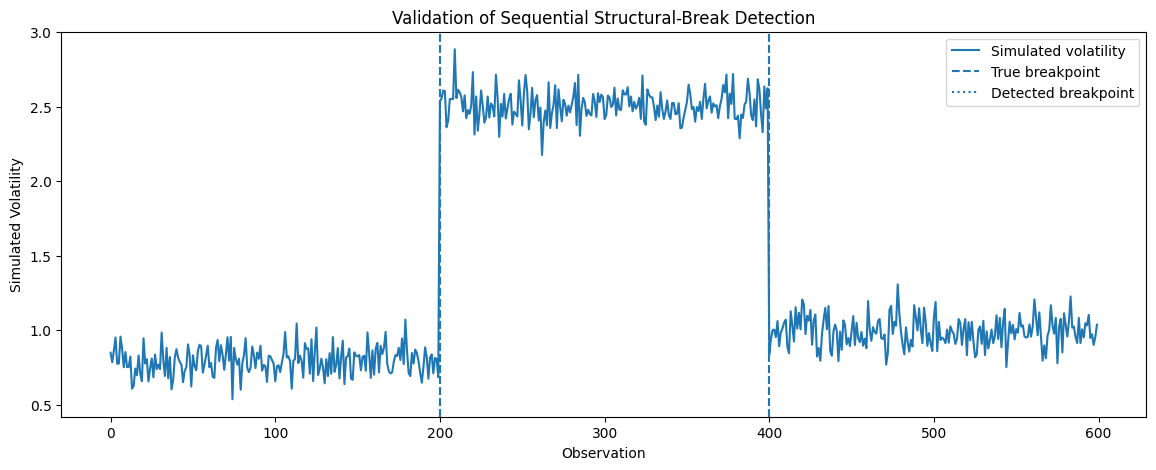

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    simulated_volatility,
    label="Simulated volatility"
)

for i, bp_true in enumerate(true_breaks):
    plt.axvline(
        bp_true,
        linestyle="--",
        label="True breakpoint" if i == 0 else None
    )

for i, bp_est in enumerate(estimated_breaks):
    plt.axvline(
        bp_est,
        linestyle=":",
        label="Detected breakpoint" if i == 0 else None
    )

plt.title("Validation of Sequential Structural-Break Detection")
plt.xlabel("Observation")
plt.ylabel("Simulated Volatility")
plt.legend()
plt.tight_layout()
plt.show()

## Validation Result

The sequential structural-break procedure correctly recovered the two
known breakpoints at observations 200 and 400. After these breaks were
introduced, the strongest remaining candidate did not exceed the
moving-block-bootstrap critical value and the procedure stopped.

This simulation provides a controlled validation of the custom
structural-break implementation before its application to estimated
conditional-volatility series. The empirical analyses using EGARCH
conditional volatility are reported separately.